# Gravitino Data Governance Example

### Config environment

In [1]:
import requests  
import json  
import pandas as pd  
from datetime import datetime  
import matplotlib.pyplot as plt  
import seaborn as sns  
  
# Gravitino server configuration  
GRAVITINO_URL = "http://gravitino:8090"  
METALAKE_NAME = "metalake_demo"  
CATALOG_NAME = "catalog_hive"  
SCHEMA_NAME = "sales"  
  
# Headers cho REST API calls  
headers = {  
    "Accept": "application/vnd.gravitino.v1+json",  
    "Content-Type": "application/json"  
}
  
print("Gravitino Data Governance Example")  
print(f"Server: {GRAVITINO_URL}")  
print(f"Metalake: {METALAKE_NAME}")

Gravitino Data Governance Example
Server: http://gravitino:8090
Metalake: metalake_demo


### Create Data Classification Tags

In [2]:
base_url = f"{GRAVITINO_URL}/api/metalakes/{METALAKE_NAME}/tags"  

tags_config = [
    {
        "name": "customer_pii",  
        "comment": "Customer personally identifiable information",  
        "properties": {  
            "data_classification": "sensitive",  
            "gdpr_applicable": "true",  
            "retention_years": "7",  
            "encryption_required": "true"  
        }  
    },  
    {
        "name": "financial_data",   
        "comment": "Financial transaction and pricing data",  
        "properties": {  
            "data_classification": "confidential",  
            "audit_required": "true",  
            "pci_dss_applicable": "true"  
        }  
    },  
    {  
        "name": "master_data",  
        "comment": "Reference and master data",  
        "properties": {  
            "data_classification": "internal",  
            "update_frequency": "low",  
            "business_critical": "true"  
        }  
    }  
]  

for tag in tags_config:  
    response = requests.post(base_url, headers=headers, json=tag)  
    if response.status_code in [200, 409]:  
        print(f"Tag '{tag['name']}' created")  
    else:  
        print(f"Failed to create tag '{tag['name']}': {response.text}")

Tag 'customer_pii' created
Tag 'financial_data' created
Tag 'master_data' created


### Create Governance Policies

In [7]:
base_url = f"{GRAVITINO_URL}/api/metalakes/{METALAKE_NAME}/policies"  
  
policies_config = [  
    {  
        "name": "gdpr_customer_policy",  
        "comment": "GDPR compliance for customer data",  
        "policyType": "custom",  
        "enabled": True,  
        "content": {  
            "customRules": {  
                "data_retention_days": 2555,  
                "right_to_be_forgotten": True,  
                "consent_tracking": True,  
                "data_minimization": True,  
                "access_logging": True  
            },  
            "supportedObjectTypes": ["TABLE", "COLUMN"],  
            "properties": {  
                "compliance_framework": "GDPR",
                "applies_to_tags": "customer_pii"
            }  
        }  
    },  
    {  
        "name": "financial_security_policy",  
        "comment": "Security policy for financial data",  
        "policyType": "custom",   
        "enabled": True,  
        "content": {  
            "customRules": {  
                "encryption_at_rest": True,  
                "encryption_in_transit": True,  
                "access_approval_required": True,  
                "audit_all_access": True,  
                "backup_frequency": "daily"  
            },  
            "supportedObjectTypes": ["TABLE", "SCHEMA"],  
            "properties": {  
                "security_level": "high",  
                "applies_to_tags": "financial_data" 
            }  
        }  
    }  
]  
  
for policy in policies_config:  
    response = requests.post(base_url, headers=headers, json=policy)  
    if response.status_code in [200, 409]:  
        print(f"Policy '{policy['name']}' created")  
    else:  
        print(f"Failed to create policy '{policy['name']}': {response.text}")

Policy 'gdpr_customer_policy' created
Policy 'financial_security_policy' created


### Associate tags with tables

In [8]:
table_tags_mapping = {  
    "customers": ["customer_pii"],
    "sales": ["financial_data", "customer_pii"],
    "products": ["financial_data", "master_data"],  
    "categories": ["master_data"],
    "stores": ["master_data"] 
}  
  
tag_results = {}  
  
for table, tags_to_add in table_tags_mapping.items():  
    table_full_name = f"{CATALOG_NAME}.{SCHEMA_NAME}.{table}"  
    url = f"{GRAVITINO_URL}/api/metalakes/{METALAKE_NAME}/objects/table/{table_full_name}/tags"  
      
    payload = {  
        "tagsToAdd": tags_to_add,  
        "tagsToRemove": []  
    }  
      
    response = requests.post(url, headers=headers, json=payload)  
    if response.status_code == 200:  
        tag_results[table] = {"status": "success", "tags": tags_to_add}  
        print(f"Applied tags {tags_to_add} to table '{table}'")  
    else:  
        tag_results[table] = {"status": "failed", "error": response.text}  
        print(f"Failed to apply tags to table '{table}': {response.text}")  
    
df_tags = pd.DataFrame([  
    {"Table": table, "Tags": ", ".join(data["tags"]), "Status": data["status"]}  
    for table, data in tag_results.items() if data["status"] == "success"  
])  
  
print("\nTags Applied to Tables:")  
print(df_tags.to_string(index=False))

Applied tags ['customer_pii'] to table 'customers'
Applied tags ['financial_data', 'customer_pii'] to table 'sales'
Applied tags ['financial_data', 'master_data'] to table 'products'
Applied tags ['master_data'] to table 'categories'
Applied tags ['master_data'] to table 'stores'

Tags Applied to Tables:
     Table                         Tags  Status
 customers                 customer_pii success
     sales financial_data, customer_pii success
  products  financial_data, master_data success
categories                  master_data success
    stores                  master_data success


### Associate policies with tables

In [9]:
# Mapping policies with tables base on tags  
table_policies_mapping = {  
    "customers": ["gdpr_customer_policy"],  
    "sales": ["gdpr_customer_policy", "financial_security_policy"],  
    "products": ["financial_security_policy"]  
}  
  
policy_results = {}  
  
for table, policies_to_add in table_policies_mapping.items():  
    table_full_name = f"{CATALOG_NAME}.{SCHEMA_NAME}.{table}"  
    url = f"{GRAVITINO_URL}/api/metalakes/{METALAKE_NAME}/objects/table/{table_full_name}/policies"  
      
    payload = {  
        "policiesToAdd": policies_to_add,  
        "policiesToRemove": []  
    }  
      
    response = requests.post(url, headers=headers, json=payload)  
    if response.status_code == 200:  
        policy_results[table] = {"status": "success", "policies": policies_to_add}  
        print(f"Applied policies {policies_to_add} to table '{table}'")  
    else:  
        policy_results[table] = {"status": "failed", "error": response.text}  
        print(f"Failed to apply policies to table '{table}': {response.text}")  

df_policies = pd.DataFrame([  
    {"Table": table, "Policies": ", ".join(data["policies"]), "Status": data["status"]}  
    for table, data in policy_results.items() if data["status"] == "success"  
])  
  
print("\nPolicies Applied to Tables:")  
print(df_policies.to_string(index=False))

Applied policies ['gdpr_customer_policy'] to table 'customers'
Applied policies ['gdpr_customer_policy', 'financial_security_policy'] to table 'sales'
Applied policies ['financial_security_policy'] to table 'products'

Policies Applied to Tables:
    Table                                        Policies  Status
customers                            gdpr_customer_policy success
    sales gdpr_customer_policy, financial_security_policy success
 products                       financial_security_policy success


### Update statistics for tables

In [10]:
table_statistics = {  
    "stores": {  
        "custom-row_count": "7", 
        "custom-unique_locations": "5",  
        "custom-data_quality_score": "0.85",
        "custom-last_updated": "2024-12-29",  
        "custom-geographic_coverage": "5_states"  
    },  
      
    "categories": {  
        "custom-row_count": "10",  
        "custom-category_coverage": "complete",  
        "custom-data_quality_score": "1.0",
        "custom-last_updated": "2024-12-29",  
        "custom-business_domains": "kitchen_home"  
    },  
      
    "products": {  
        "custom-row_count": "32",
        "custom-unique_products": "25",
        "custom-price_range_min": "12.99",  
        "custom-price_range_max": "399.99",  
        "custom-avg_price": "89.45",  
        "custom-data_quality_score": "0.78", 
        "custom-high_value_products": "3",
        "custom-category_distribution": "balanced"  
    },  
      
    "customers": {  
        "custom-row_count": "10",  
        "custom-pii_columns_count": "2", 
        "custom-email_domains": "6", 
        "custom-gdpr_compliance_score": "0.95",  
        "custom-data_quality_score": "1.0",
        "custom-privacy_risk_level": "high"  
    },  
      
    "sales": {  
        "custom-row_count": "48", 
        "custom-unique_transactions": "24", 
        "custom-total_revenue": "8847.33",
        "custom-avg_transaction_value": "184.32",  
        "custom-date_range_start": "2022-04-24",  
        "custom-date_range_end": "2023-11-28",  
        "custom-active_customers": "8",  
        "custom-active_stores": "7",
        "custom-data_freshness_days": "31",
        "custom-revenue_concentration": "0.25", 
        "custom-seasonal_pattern": "detected"  
    }  
}   

statistic_results = {}  
  
for table, stats in table_statistics.items():  
    table_full_name = f"{CATALOG_NAME}.{SCHEMA_NAME}.{table}"  
    url = f"{GRAVITINO_URL}/api/metalakes/{METALAKE_NAME}/objects/table/{table_full_name}/statistics"  
      
    # Convert string values to proper StatisticValue format  
    formatted_stats = {}  
    for key, value in stats.items():  
        if value.replace(".", "").isdigit():  
            formatted_stats[key] = float(value) if "." in value else int(value)  
        else:  
            formatted_stats[key] = value  
      
    payload = {"updates": formatted_stats}  
      
    response = requests.put(url, headers=headers, json=payload)  
    if response.status_code == 200:  
        statistic_results[table] = {"status": "success", "stats_count": len(stats)}  
        print(f"Updated {len(stats)} statistics for table '{table}'")  
    else:  
        statistic_results[table] = {"status": "failed", "error": response.text}  
        print(f"Failed to update statistics for table '{table}': {response.text}")  
  
print(f"\n Statistics updated for {len([r for r in statistic_results.values() if r['status'] == 'success'])} tables")

Updated 5 statistics for table 'stores'
Updated 5 statistics for table 'categories'
Updated 8 statistics for table 'products'
Updated 6 statistics for table 'customers'
Updated 11 statistics for table 'sales'

 Statistics updated for 5 tables


### Governance dashboard

GOVERNANCE OVERVIEW:
     Table                         Tags                                        Policies  Row_Count Risk_Level  Tag_Count  Policy_Count
 customers                 customer_pii                            gdpr_customer_policy         10        Low          1             1
     sales financial_data, customer_pii gdpr_customer_policy, financial_security_policy         48     Medium          2             2
  products  financial_data, master_data                       financial_security_policy         32        Low          2             1
categories                  master_data                                                         10        Low          1             0
    stores                  master_data                                                          7        Low          1             0


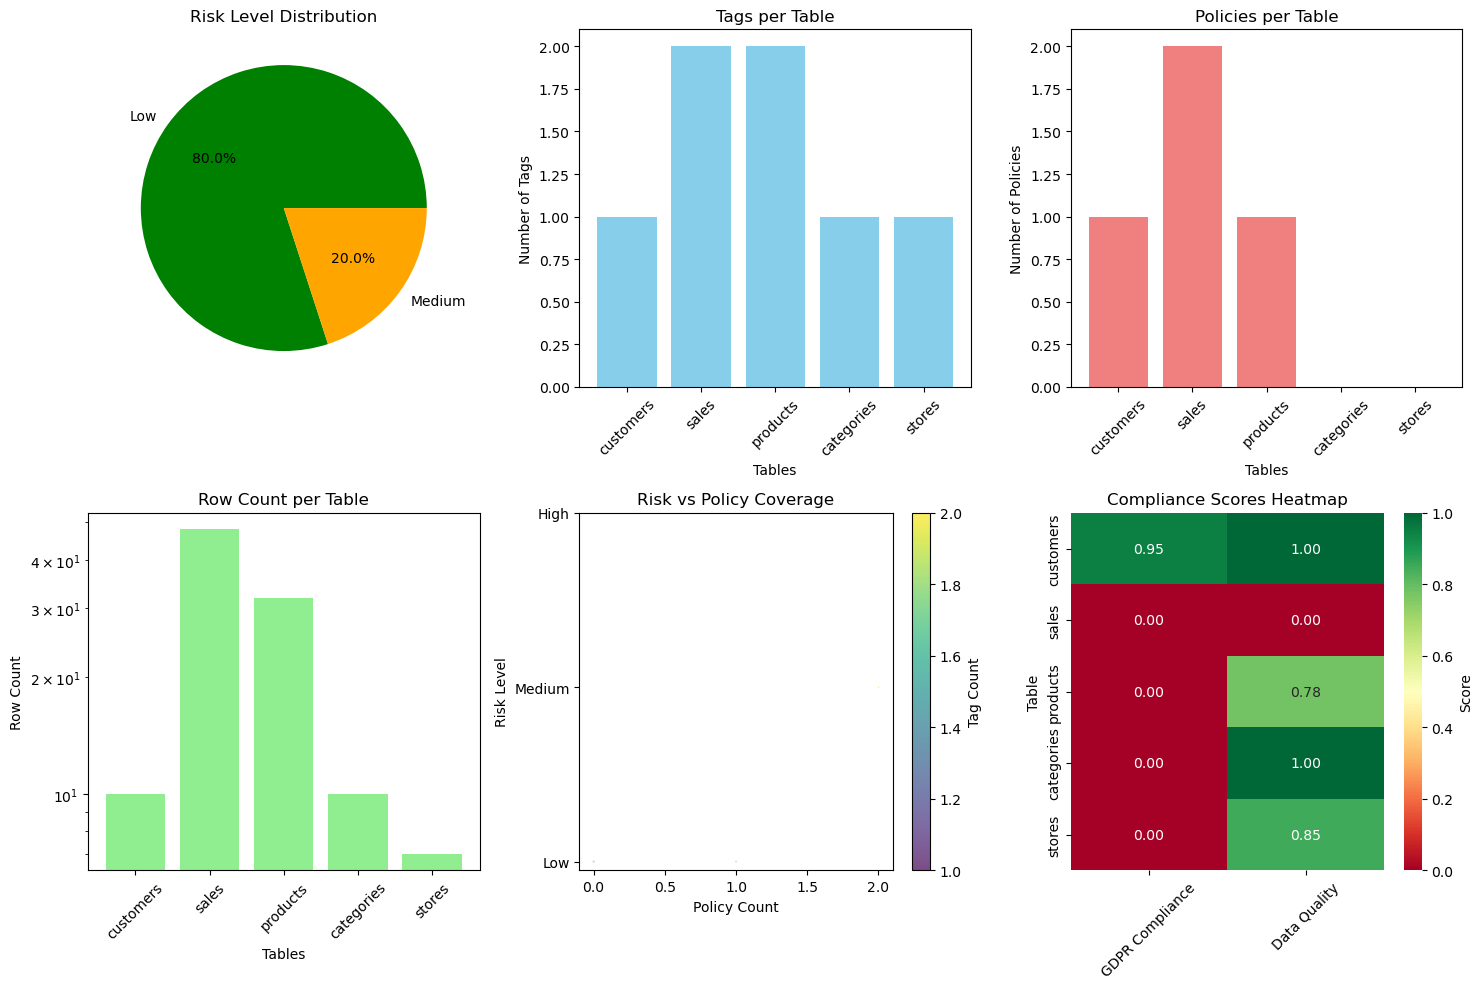

In [13]:
governance_data = []  
  
for table in ["customers", "sales", "products", "categories", "stores"]:    
    table_tags = tag_results.get(table, {}).get("tags", [])    
    table_policies = policy_results.get(table, {}).get("policies", [])  
    table_stats = table_statistics.get(table, {})  
    row_count = int(table_stats.get("custom-row_count", 0))  

    # Compute risk level
    risk_level = "Low"  
    if "customer_pii" in table_tags and "financial_data" in table_tags:  
        risk_level = "High" if len(table_policies) < 2 else "Medium"  
    elif "customer_pii" in table_tags or "financial_data" in table_tags:  
        risk_level = "Medium" if len(table_policies) == 0 else "Low"  

    governance_data.append({  
        "Table": table,  
        "Tags": ", ".join(table_tags),  
        "Policies": ", ".join(table_policies),  
        "Row_Count": row_count,  
        "Risk_Level": risk_level,  
        "Tag_Count": len(table_tags),  
        "Policy_Count": len(table_policies)  
    })  
  
df_governance = pd.DataFrame(governance_data)  
  
# 1. Overview  
print("GOVERNANCE OVERVIEW:")  
print(df_governance.to_string(index=False))  
  
# 2. Visualization - Risk Level Distribution  
plt.figure(figsize=(15, 10))  
  
# Subplot 1: Risk Level Distribution  
plt.subplot(2, 3, 1)  
risk_counts = df_governance['Risk_Level'].value_counts()  
colors = {'High': 'red', 'Medium': 'orange', 'Low': 'green'}  
plt.pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',  
        colors=[colors[level] for level in risk_counts.index])  
plt.title('Risk Level Distribution')  
  
# Subplot 2: Tags per Table  
plt.subplot(2, 3, 2)  
plt.bar(df_governance['Table'], df_governance['Tag_Count'], color='skyblue')  
plt.title('Tags per Table')  
plt.xlabel('Tables')  
plt.ylabel('Number of Tags')  
plt.xticks(rotation=45)  
  
# Subplot 3: Policies per Table  
plt.subplot(2, 3, 3)  
plt.bar(df_governance['Table'], df_governance['Policy_Count'], color='lightcoral')  
plt.title('Policies per Table')  
plt.xlabel('Tables')  
plt.ylabel('Number of Policies')  
plt.xticks(rotation=45)  
  
# Subplot 4: Row Count Distribution  
plt.subplot(2, 3, 4)  
plt.bar(df_governance['Table'], df_governance['Row_Count'], color='lightgreen')  
plt.title('Row Count per Table')  
plt.xlabel('Tables')  
plt.ylabel('Row Count')  
plt.xticks(rotation=45)  
plt.yscale('log')  # Log scale for better visualization  
  
# Subplot 5: Risk vs Coverage Matrix  
plt.subplot(2, 3, 5)  
risk_mapping = {'Low': 1, 'Medium': 2, 'High': 3}  
df_governance['Risk_Numeric'] = df_governance['Risk_Level'].map(risk_mapping)  
  
scatter = plt.scatter(df_governance['Policy_Count'], df_governance['Risk_Numeric'],   
                     c=df_governance['Tag_Count'], s=df_governance['Row_Count']/1000,  
                     alpha=0.7, cmap='viridis')  
plt.xlabel('Policy Count')  
plt.ylabel('Risk Level')  
plt.yticks([1, 2, 3], ['Low', 'Medium', 'High'])  
plt.title('Risk vs Policy Coverage')  
plt.colorbar(scatter, label='Tag Count')  
  
# Subplot 6: Compliance Score Heatmap  
plt.subplot(2, 3, 6)  
  
# Tạo compliance matrix  
compliance_matrix = []  
for table in df_governance['Table']:  
    table_stats = table_statistics.get(table, {})  
    gdpr_score = float(table_stats.get("custom-gdpr_compliance_score", 0))  
    data_quality = float(table_stats.get("custom-data_quality_score", 0))  
    compliance_matrix.append([gdpr_score, data_quality])  
  
compliance_df = pd.DataFrame(compliance_matrix,   
                            columns=['GDPR Compliance', 'Data Quality'],  
                            index=df_governance['Table'])  
  
sns.heatmap(compliance_df, annot=True, cmap='RdYlGn', vmin=0, vmax=1,  
            fmt='.2f', cbar_kws={'label': 'Score'})  
plt.title('Compliance Scores Heatmap')  
plt.xticks(rotation=45)  
  
plt.tight_layout()  
plt.show()

### Governance Report

In [12]:
print("\n" + "="*60)  
print("DETAILED COMPLIANCE REPORT")  
print("="*60)  
print(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")  
  
# 1. Executive Summary  
print("\nEXECUTIVE SUMMARY:")  
total_tables = len(df_governance)  
high_risk_count = len(df_governance[df_governance['Risk_Level'] == 'High'])  
medium_risk_count = len(df_governance[df_governance['Risk_Level'] == 'Medium'])  
low_risk_count = len(df_governance[df_governance['Risk_Level'] == 'Low'])  
  
print(f"   • Total Tables Analyzed: {total_tables}")  
print(f"   • High Risk Tables: {high_risk_count} ({high_risk_count/total_tables*100:.1f}%)")  
print(f"   • Medium Risk Tables: {medium_risk_count} ({medium_risk_count/total_tables*100:.1f}%)")  
print(f"   • Low Risk Tables: {low_risk_count} ({low_risk_count/total_tables*100:.1f}%)")  
  
# 2. Data Classification Analysis  
print("\nDATA CLASSIFICATION ANALYSIS:")  
pii_tables = df_governance[df_governance['Tags'].str.contains('customer_pii', na=False)]  
financial_tables = df_governance[df_governance['Tags'].str.contains('financial_data', na=False)]  
master_tables = df_governance[df_governance['Tags'].str.contains('master_data', na=False)]  
  
print(f"   • Tables with PII Data: {len(pii_tables)} - {list(pii_tables['Table'])}")  
print(f"   • Tables with Financial Data: {len(financial_tables)} - {list(financial_tables['Table'])}")  
print(f"   • Master Data Tables: {len(master_tables)} - {list(master_tables['Table'])}")  
  
# 3. Policy Coverage Analysis  
print("\nPOLICY COVERAGE ANALYSIS:")  
tables_with_policies = df_governance[df_governance['Policy_Count'] > 0]  
tables_without_policies = df_governance[df_governance['Policy_Count'] == 0]  
  
print(f"   • Tables with Policies: {len(tables_with_policies)} ({len(tables_with_policies)/total_tables*100:.1f}%)")  
print(f"   • Tables without Policies: {len(tables_without_policies)} ({len(tables_without_policies)/total_tables*100:.1f}%)")  
  
if len(tables_without_policies) > 0:  
    print(f"   • Unprotected Tables: {list(tables_without_policies['Table'])}")  
  
# 4. Detailed Table Analysis  
print("\nDETAILED TABLE ANALYSIS:")  
for _, row in df_governance.iterrows():  
    table_name = row['Table']  
    risk_level = row['Risk_Level']  
      
    # Risk indicator  
    risk_emoji = {"High": "🔴", "Medium": "🟡", "Low": "🟢"}  
      
    print(f"\n   {risk_emoji[risk_level]} TABLE: {table_name.upper()}")  
    print(f"      Risk Level: {risk_level}")  
    print(f"      Tags: {row['Tags'] if row['Tags'] else 'None'}")  
    print(f"      Policies: {row['Policies'] if row['Policies'] else 'None'}")  
    print(f"      Row Count: {row['Row_Count']:,}")  
      
    # Get detailed statistics  
    table_stats = table_statistics.get(table_name, {})  
    if table_stats:  
        print("      Statistics:")  
        for key, value in table_stats.items():  
            if key.startswith("custom-"):  
                clean_key = key.replace("custom-", "").replace("_", " ").title()  
                print(f"        • {clean_key}: {value}")  
  
# 5. Recommendations  
print("\nRECOMMENDATIONS:")  
  
# High priority recommendations  
if high_risk_count > 0:  
    print("  HIGH PRIORITY:")  
    high_risk_tables = df_governance[df_governance['Risk_Level'] == 'High']['Table'].tolist()  
    print(f"      • Apply comprehensive governance policies to: {', '.join(high_risk_tables)}")  
    print("      • Implement encryption for sensitive data")  
    print("      • Set up access logging and monitoring")  
  
# Medium priority recommendations    
if medium_risk_count > 0:  
    print("   MEDIUM PRIORITY:")  
    medium_risk_tables = df_governance[df_governance['Risk_Level'] == 'Medium']['Table'].tolist()  
    print(f"      • Review and apply appropriate policies to: {', '.join(medium_risk_tables)}")  
    print("      • Implement data quality monitoring")  
  
# General recommendations  
print("   GENERAL:")  
print("      • Regular compliance audits (quarterly)")  
print("      • Data lineage tracking implementation")  
print("      • Staff training on data governance policies")  
  
# 6. Compliance Score  
total_compliance_score = 0  
scored_tables = 0  
  
for table in df_governance['Table']:  
    table_stats = table_statistics.get(table, {})  
    if 'custom-gdpr_compliance_score' in table_stats:  
        total_compliance_score += float(table_stats['custom-gdpr_compliance_score'])  
        scored_tables += 1  
  
if scored_tables > 0:  
    avg_compliance = total_compliance_score / scored_tables  
    print(f"\nOVERALL COMPLIANCE SCORE: {avg_compliance*100:.1f}%")  
      
    if avg_compliance >= 0.95:  
        print("   EXCELLENT - Compliance standards exceeded")  
    elif avg_compliance >= 0.90:  
        print("   GOOD - Meeting compliance requirements")  
    elif avg_compliance >= 0.80:  
        print("   NEEDS IMPROVEMENT - Below optimal compliance")  
    else:  
        print("   CRITICAL - Immediate action required")  
  
print("\n" + "="*60)  
print("END OF COMPLIANCE REPORT")  
print("="*60)


DETAILED COMPLIANCE REPORT
Generated: 2025-09-29 08:36:47

EXECUTIVE SUMMARY:
   • Total Tables Analyzed: 5
   • High Risk Tables: 0 (0.0%)
   • Medium Risk Tables: 1 (20.0%)
   • Low Risk Tables: 4 (80.0%)

DATA CLASSIFICATION ANALYSIS:
   • Tables with PII Data: 2 - ['customers', 'sales']
   • Tables with Financial Data: 2 - ['sales', 'products']
   • Master Data Tables: 3 - ['products', 'categories', 'stores']

POLICY COVERAGE ANALYSIS:
   • Tables with Policies: 3 (60.0%)
   • Tables without Policies: 2 (40.0%)
   • Unprotected Tables: ['categories', 'stores']

DETAILED TABLE ANALYSIS:

   🟢 TABLE: CUSTOMERS
      Risk Level: Low
      Tags: customer_pii
      Policies: gdpr_customer_policy
      Row Count: 10
      Statistics:
        • Row Count: 10
        • Pii Columns Count: 2
        • Email Domains: 6
        • Gdpr Compliance Score: 0.95
        • Data Quality Score: 1.0
        • Privacy Risk Level: high

   🟡 TABLE: SALES
      Risk Level: Medium
      Tags: financial_da

### Summary

In [15]:
# Export governance data to CSV  
df_governance.to_csv('gravitino_governance_report.csv', index=False)  
print("Exported governance data to: gravitino_governance_report.csv")  
  
# Create summary statistics  
summary_stats = {  
    'total_tables': int(len(df_governance)),
    'high_risk_tables': int(len(df_governance[df_governance['Risk_Level'] == 'High'])),  
    'medium_risk_tables': int(len(df_governance[df_governance['Risk_Level'] == 'Medium'])),  
    'low_risk_tables': int(len(df_governance[df_governance['Risk_Level'] == 'Low'])),  
    'total_tags_applied': int(df_governance['Tag_Count'].sum()),  
    'total_policies_applied': int(df_governance['Policy_Count'].sum()),  
    'average_tags_per_table': float(df_governance['Tag_Count'].mean()),  
    'average_policies_per_table': float(df_governance['Policy_Count'].mean())  
}
  
# Save summary as JSON  
with open('governance_summary.json', 'w') as f:  
    json.dump(summary_stats, f, indent=2)  
  
print("Exported summary statistics to: governance_summary.json")  
  
# Final summary  
print("\nDEMO COMPLETED SUCCESSFULLY!")
  
print(f"\nSUMMARY METRICS:")  
for key, value in summary_stats.items():  
    formatted_key = key.replace('_', ' ').title()  
    if isinstance(value, float):  
        print(f"   • {formatted_key}: {value:.2f}")  
    else:  
        print(f"   • {formatted_key}: {value}")  

Exported governance data to: gravitino_governance_report.csv
Exported summary statistics to: governance_summary.json

DEMO COMPLETED SUCCESSFULLY!

SUMMARY METRICS:
   • Total Tables: 5
   • High Risk Tables: 0
   • Medium Risk Tables: 1
   • Low Risk Tables: 4
   • Total Tags Applied: 7
   • Total Policies Applied: 4
   • Average Tags Per Table: 1.40
   • Average Policies Per Table: 0.80


### Clean up

In [6]:
import requests  
  
def cleanup_governance_demo():  
    GRAVITINO_URL = "http://gravitino:8090"  
    METALAKE_NAME = "metalake_demo"  
      
    headers = {  
        "Accept": "application/vnd.gravitino.v1+json",  
        "Content-Type": "application/json"  
    }  
      
    print("🧹 Starting fixed cleanup process...")  
      
    # 1. Xóa tag associations bằng REST API  
    tables = ["customers", "sales", "products", "categories", "stores"]  
    for table in tables:  
        try:  
            # Disassociate tất cả tags  
            url = f"{GRAVITINO_URL}/api/metalakes/{METALAKE_NAME}/objects/table/catalog_hive.sales.{table}/tags"  
              
            # Lấy danh sách tags hiện tại  
            response = requests.get(url, headers=headers)  
            if response.status_code == 200:  
                current_tags = response.json().get("names", [])  
                if current_tags:  
                    # Xóa tất cả tags  
                    payload = {"tagsToAdd": [], "tagsToRemove": current_tags}  
                    requests.post(url, headers=headers, json=payload)  
                    print(f"✅ Removed tags from table {table}")  
        except Exception as e:  
            print(f"⚠️ Error removing tags from {table}: {e}")  
      
    # 2. Xóa policy associations bằng REST API  
    for table in tables:  
        try:  
            url = f"{GRAVITINO_URL}/api/metalakes/{METALAKE_NAME}/objects/table/catalog_hive.sales.{table}/policies"  
              
            # Lấy danh sách policies hiện tại  
            response = requests.get(url, headers=headers)  
            if response.status_code == 200:  
                current_policies = response.json().get("names", [])  
                if current_policies:  
                    # Xóa tất cả policies  
                    payload = {"policiesToAdd": [], "policiesToRemove": current_policies}  
                    requests.post(url, headers=headers, json=payload)  
                    print(f"✅ Removed policies from table {table}")  
        except Exception as e:  
            print(f"⚠️ Error removing policies from {table}: {e}")  
      
    # 3. Xóa tags bằng REST API  
    tags_to_delete = ["customer_pii", "financial_data", "master_data"]  
    for tag in tags_to_delete:  
        try:  
            url = f"{GRAVITINO_URL}/api/metalakes/{METALAKE_NAME}/tags/{tag}"  
            response = requests.delete(url, headers=headers)  
            if response.status_code == 200:  
                print(f"✅ Deleted tag: {tag}")  
            else:  
                print(f"⚠️ Failed to delete tag {tag}: {response.text}")  
        except Exception as e:  
            print(f"⚠️ Error deleting tag {tag}: {e}")  
      
    # 4. Xóa policies bằng REST API  
    policies_to_delete = ["gdpr_customer_policy", "financial_security_policy"]  
    for policy in policies_to_delete:  
        try:  
            url = f"{GRAVITINO_URL}/api/metalakes/{METALAKE_NAME}/policies/{policy}"  
            response = requests.delete(url, headers=headers)  
            if response.status_code == 200:  
                print(f"✅ Deleted policy: {policy}")  
            else:  
                print(f"⚠️ Failed to delete policy {policy}: {response.text}")  
        except Exception as e:  
            print(f"⚠️ Error deleting policy {policy}: {e}")  
      
    print("🎉 Fixed cleanup completed!")  
  
if __name__ == "__main__":  
    cleanup_governance_demo()

🧹 Starting fixed cleanup process...
✅ Removed tags from table customers
✅ Removed tags from table sales
✅ Removed tags from table products
✅ Removed tags from table categories
✅ Removed tags from table stores
✅ Deleted tag: customer_pii
✅ Deleted tag: financial_data
✅ Deleted tag: master_data
✅ Deleted policy: gdpr_customer_policy
✅ Deleted policy: financial_security_policy
🎉 Fixed cleanup completed!
